# Utilities

In [2]:
from imports import *

# Assignment 

## Assignment 4.1

In [3]:
#TODO Build a proxi gradient step visualization
#TODO Build a gradient step visualization
train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')
examples = enumerate(train)
_, (x_clean_example, x_noisy_example, labels_example) = next(examples)

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
C:\Users\The Cristi\AppData\Local\Temp\ipykernel_22152\1658719758.py:3: SyntaxWarning: invalid escape sequence '\D'
  train, valid, test = create_dataloaders(batch_size=64, data_loc='\DataLoc')


# Helpers or standalone methods

In [4]:
import torch
import torch.nn.functional as F

@staticmethod
def ista(miu:float, shrink:float, no_iterations:int, y:torch.tensor)->torch.tensor:

    # 1.1 Wrap the required definitions in a private function,
    # ... of the members used in both, gradient and proximal steps;
    def _proximal_elements_definition(measurement=y):
        A_def:float = 1.0
        L_def:float = 1.0
        # Initialize the unknown signal X to match the measurement shape
        x_def = measurement.clone() 
        return L_def, A_def, x_def
        
    L, A, X = _proximal_elements_definition() # L is required to define the threshold

    def shrinkage_fn(current_x, lambd=shrink, measurement=y):
        # Incorporating the required step size `miu` into the scalar terms
        W_y = miu * A 
        W_x = 1.0 - (miu * A * A)
        theta = lambd * miu

        # 2. ReLU definition wrapped in a private function;
        # Matrix multiplications (@) replaced with scalar multiplications (*)
        u = W_y * measurement + W_x * current_x
        
        # Accommodating the -1 background hint natively
        u_shifted = u + 1.0 
        
        # Using F.relu to cleanly process the maximum condition
        rec = F.relu(u_shifted - theta) - F.relu(-u_shifted - theta)
        
        # Shift back to the -1 background
        rec = rec - 1.0

        return rec, (W_y, W_x, theta)

    for iter in range(no_iterations):
        # Update the evolving signal X, while keeping the original measurement y fixed
        X, _ = shrinkage_fn(current_x=X)

    return X

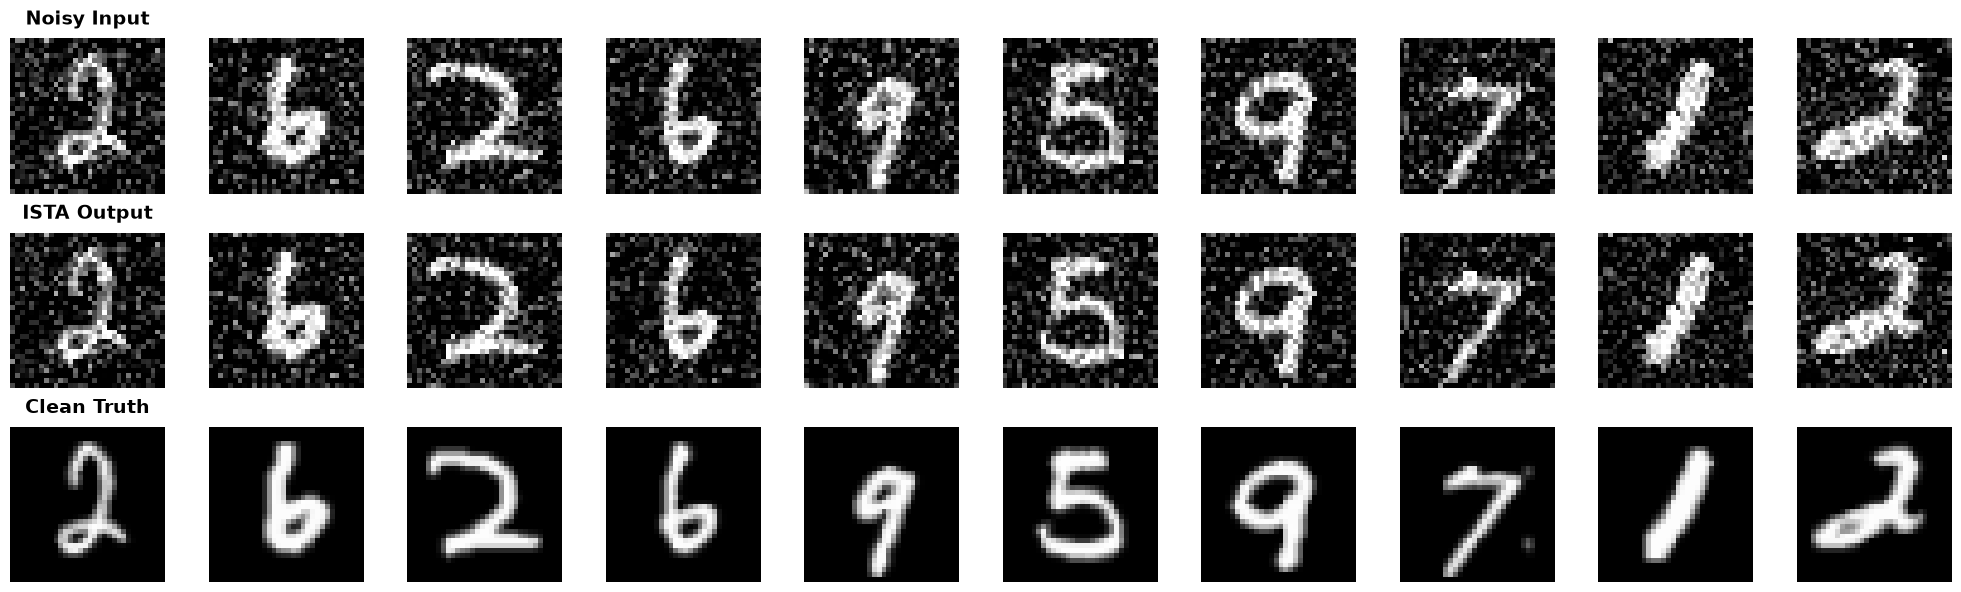

In [ ]:

# Assuming x_noisy_example and x_clean_example are already loaded from your dataset
#TODO Play with each of these parameters until you reach the same values yourself;
#TODO Document the behavior of the ista based on the parameters;
ista_reconstructions = ista(miu=0.1, shrink=0.05, no_iterations=300, y=x_noisy_example)

# Pull tensors back to CPU and convert to numpy for Matplotlib
#TODO Document the function again based on your commentaries
#TODO Dismantled extraneous code commands (e.g., squezee())
noisy_np = x_noisy_example.cpu().squeeze().numpy()
recon_np = ista_reconstructions.cpu().squeeze().numpy()
clean_np = x_clean_example.cpu().squeeze().numpy()

# =====================================================================
# --- 2. PLOT THE 3x10 GRID ---
# =====================================================================
fig, axes = PLT.subplots(nrows=3, ncols=10, figsize=(20, 6))

for i in range(10):
    # ROW 1: Noisy Measurement (y)
    axes[0, i].imshow(noisy_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title("Noisy Input", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 2: ISTA Reconstruction (x_K)
    axes[1, i].imshow(recon_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title("ISTA Output", fontsize=14, fontweight='bold', pad=10)
    
    # ROW 3: Ground Truth Target (x)
    axes[2, i].imshow(clean_np[i], cmap='gray', vmin=-1, vmax=1)
    axes[2, i].axis('off')
    if i == 0: axes[2, i].set_title("Clean Truth", fontsize=14, fontweight='bold', pad=10)

PLT.tight_layout()
PLT.show()